In [1]:
import numpy as np 
import pandas as pd 
from scipy.stats import gmean
import matplotlib.pyplot as plt 
from mosqlient.scoring import compute_wis
import sys
sys.path.append('../')
from aux_func import get_data, code_to_state 

In [2]:
challenge = 'dengue_state'

Load data: 

In [3]:
df_dengue_state = get_data('dengue_state')
df_dengue_state.date = pd.to_datetime(df_dengue_state.date)
df_dengue_state.head()

,date,adm_1,casos
0,2010-01-03,11,2456
1,2010-01-03,12,760
2,2010-01-03,13,155
3,2010-01-03,14,25
4,2010-01-03,15,115


Load ranking: 

In [4]:
df_rank = pd.read_csv(f'../predictions/rank_ratio_{challenge}.csv')

model_baseline = '3rd_imdc_procc_bb_model'

df_rank = df_rank.loc[df_rank.model != model_baseline]

df_rank_all = (
    df_rank
    .groupby(["adm_1", "model"], as_index=False)
    .agg(
        geometric_mean_ratio=("wis_ratio", lambda x: np.exp(np.mean(np.log(x)))),
    )
    .sort_values(["adm_1", "geometric_mean_ratio"])
)


df_rank_all['rank'] = df_rank_all.groupby('adm_1')['geometric_mean_ratio'].rank()

df_rank_all.head()

,adm_1,model,geometric_mean_ratio,rank
6,11,3rd_imdc_emap_epidematicos_sarimax_state,0.769598,1.0
19,11,3rd_imdc_pucrio_arbocaster,0.789304,2.0
16,11,3rd_imdc_lncc_lncc_arp26_dengue,0.800598,3.0
13,11,3rd_imdc_ifgw_inframind-proteus,0.845450,4.0
21,11,3rd_imdc_rki_rki_zki_ph,0.893327,5.0


Load predictions: 

In [5]:
df_preds = pd.read_csv(f'../predictions/predictions_all_models_{challenge}.csv.gz', index_col = 'Unnamed: 0')
df_preds.date = pd.to_datetime(df_preds.date)
df_preds.head()

,date,lower_95,lower_90,lower_80,lower_50,pred,upper_50,upper_80,upper_90,upper_95,adm_1,id,validation,wis,model
0,2022-10-09,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,12,6822,1,95.67,3rd_imdc_isi_isi-dengue
1,2022-10-16,37.019327,43.295517,51.743385,66.653189,83.207109,100.790847,116.992117,126.864602,134.406880,12,6822,1,95.67,3rd_imdc_isi_isi-dengue
2,2022-10-23,55.945220,68.411390,84.200302,108.887826,135.698419,163.344639,189.017119,205.765306,218.575663,12,6822,1,95.67,3rd_imdc_isi_isi-dengue
3,2022-10-30,58.185781,69.697014,83.792687,107.076328,132.601767,158.745145,184.276095,201.204977,212.912726,12,6822,1,95.67,3rd_imdc_isi_isi-dengue
4,2022-11-06,58.634062,68.591352,80.855678,101.969117,125.548661,150.259612,174.517426,190.524410,202.512661,12,6822,1,95.67,3rd_imdc_isi_isi-dengue


Compute the wis given the top K models

wis baseline: 

In [6]:
df_preds.columns

Index(['date', 'lower_95', 'lower_90', 'lower_80', 'lower_50', 'pred',
       'upper_50', 'upper_80', 'upper_90', 'upper_95', 'adm_1', 'id',
       'validation', 'wis', 'model'],
      dtype='str')

In [7]:
df_preds_base = df_preds.loc[df_preds.model == model_baseline][['date', 
                                                'adm_1', 
                                                'lower_95', 'lower_90', 'lower_80', 'lower_50', 'pred',
       'upper_50', 'upper_80', 'upper_90', 'upper_95']].merge(df_dengue_state, on = ['date', 'adm_1'])

list_dfs = [] 

for adm in df_preds_base.adm_1.unique(): 

       df_ = df_preds_base.loc[(df_preds_base.adm_1 == adm)]

       wis = np.mean(compute_wis(

       df = df_[['date', 'lower_95', 'lower_90', 'lower_80', 'lower_50', 'pred',
                        'upper_50', 'upper_80', 'upper_90', 'upper_95']],
            observed_value=  df_['casos']))

       list_dfs.append(pd.DataFrame([[adm, wis]], columns = ['adm_1', 'WIS' ]))


df_wis_base = pd.concat(list_dfs, ignore_index=True)

df_wis_base.head()

,adm_1,WIS
0,12,45.008233
1,27,68.209884
2,13,32.801203
3,16,57.245825
4,29,1007.299118


### Metodologia 1 

Olhar para a média do WIS no período completo:

In [8]:
def get_wis_model(df_preds, df_dengue_state, df_rk_1, wis_base, rank = 2):

    df_rk_1 = df_rk_1.loc[df_rk_1.adm_1 != 32] 

    list_dfs = [] 

    for adm in df_rk_1.adm_1.unique(): 


        models = df_rk_1.loc[(df_rk_1.adm_1 == adm) & (df_rk_1['rank'] <= rank)].model.unique()

        df_ = df_preds.loc[(df_preds.adm_1 == adm) & ( df_preds.model.isin(models))].groupby(['date', 'adm_1', 'validation'])[['lower_95', 'lower_90', 'lower_80', 'lower_50', 'pred',
                'upper_50', 'upper_80', 'upper_90', 'upper_95']].median().reset_index()

        df_m=df_.merge(df_dengue_state, on = ['date', 'adm_1']).sort_values(by = 'date')

        wis = np.mean(compute_wis(

        df = df_m[['date', 'lower_95', 'lower_90', 'lower_80', 'lower_50', 'pred',
                        'upper_50', 'upper_80', 'upper_90', 'upper_95']],
                observed_value=  df_m['casos']))

        max_90 = df_m['upper_90'].max()

        wis_ratio = wis/(wis_base.loc[wis_base.adm_1==adm]['WIS'].values[0])

        list_dfs.append(pd.DataFrame([[adm, wis, wis_ratio, max_90]], columns = ['adm_1', 'WIS', 'WIS_ratio', 'max_p_90']))

    df_wis_ = pd.concat(list_dfs, ignore_index=True)

    df_wis_['models_included'] = rank 

    return df_wis_

In [9]:
list_dfs = [] 

for rank in np.arange(1, 27): 

    list_dfs.append(get_wis_model(df_preds, df_dengue_state, df_rank_all, df_wis_base, rank = rank))

df_wis_rank = pd.concat(list_dfs, ignore_index = True)

df_wis_rank.head()

,adm_1,WIS,WIS_ratio,max_p_90,models_included
0,11,37.760573,0.791324,1320.941416,1
1,12,42.991473,0.955191,1667.960705,1
2,13,25.431297,0.775316,1641.868207,1
3,14,3.033120,0.857136,122.628248,1
4,15,56.707758,0.625156,1369.921974,1


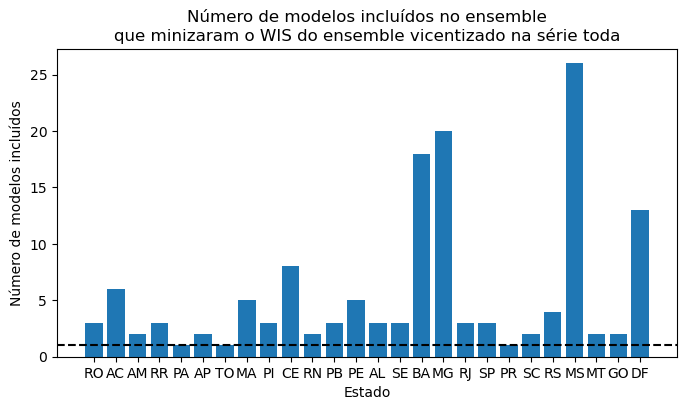

In [10]:
df_m_incl = df_wis_rank.loc[df_wis_rank.groupby('adm_1')['WIS_ratio'].idxmin(), ['adm_1', 'models_included']]

df_m_incl['state'] = df_m_incl['adm_1'].replace(code_to_state)

_,ax = plt.subplots(figsize = (8, 4))

ax.bar(df_m_incl.state, df_m_incl.models_included)

ax.axhline(1, color = 'black', linestyle = '--')

ax.set_title('Número de modelos incluídos no ensemble\nque minizaram o WIS do ensemble vicentizado na série toda')

ax.set_xlabel('Estado')
ax.set_ylabel('Número de modelos incluídos')

plt.show()


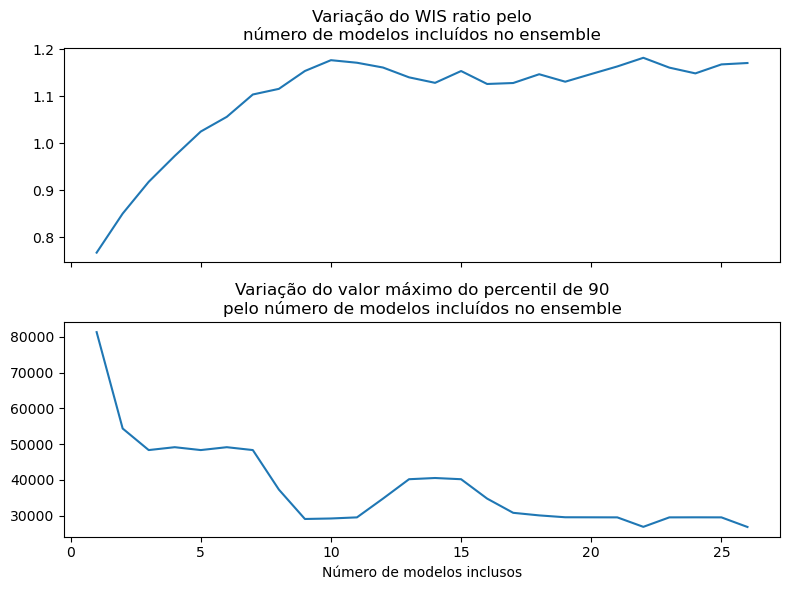

In [11]:
state = 41

df_ = df_wis_rank.loc[df_wis_rank.adm_1 == state]

_,ax = plt.subplots(2,1, figsize = (8, 6), sharex=True)

ax[0].plot(df_.models_included, df_.WIS_ratio)

ax[0].set_title('Variação do WIS ratio pelo\nnúmero de modelos incluídos no ensemble')

ax[1].plot(df_.models_included, df_.max_p_90)

ax[1].set_title('Variação do valor máximo do percentil de 90\npelo número de modelos incluídos no ensemble')

ax[1].set_xlabel('Número de modelos inclusos')

plt.tight_layout()

plt.show()


### Metodologia 2

In [12]:
df_rank.loc[(df_rank.adm_1 == 11) & (df_rank.validation == 1)]

,model,adm_1,validation,wis,wis_baseline,wis_ratio,region
0,3rd_imdc_-unifesp-_-4mosqueteiras-,11,1,205.380000,101.894535,2.015613,North
104,3rd_imdc_afya_ric,11,1,182.420000,101.894535,1.790282,North
208,3rd_imdc_bsc_ghr,11,1,127.461645,101.894535,1.250917,North
312,3rd_imdc_ceri_returnoftheforecast,11,1,96.090000,101.894535,0.943034,North
416,3rd_imdc_cornell_bentolab,11,1,76.960000,101.894535,0.755291,North
524,3rd_imdc_emap_epidematicos_prophet,11,1,96.475444,101.894535,0.946817,North
628,3rd_imdc_emap_epidematicos_sarimax_state,11,1,75.520000,101.894535,0.741158,North
732,3rd_imdc_emap_lstm,11,1,123.590000,101.894535,1.212921,North
840,3rd_imdc_emap_xgbsillas,11,1,107.000000,101.894535,1.050105,North
944,3rd_imdc_fgv_pattern-blue,11,1,167.210087,101.894535,1.641011,North


In [13]:

def get_wis_model_gmean(df_preds, df_dengue_state, df_rank_all, df_rank, label = 'rk_1', rank = 5):

    df_rank_all = df_rank_all.loc[df_rank_all.adm_1 != 32] 

    list_dfs = [] 

    for adm in df_rank_all.adm_1.unique(): 


        models = df_rank_all.loc[(df_rank_all.adm_1 == adm) & (df_rank_all['rank'] <= rank)].model.unique()

        df_ = df_preds.loc[(df_preds.adm_1 == adm) & ( df_preds.model.isin(models))].groupby(['date', 'adm_1', 'validation'])[['lower_95', 'lower_90', 'lower_80', 'lower_50', 'pred',
                'upper_50', 'upper_80', 'upper_90', 'upper_95']].median().reset_index()

        df_m=df_.merge(df_dengue_state, on = ['date', 'adm_1']).sort_values(by = 'date')


        wis_v = []  
        for val in [1,2,3,4]:

                wis_base = df_rank.loc[(df_rank.adm_1 == adm) & (df_rank.validation == val)]['wis_baseline'].values[0] 

                wis = np.mean(compute_wis(
                df = df_m.loc[df_m.validation == val][['date', 'lower_95', 'lower_90', 'lower_80', 'lower_50', 'pred',
                        'upper_50', 'upper_80', 'upper_90', 'upper_95']],
                observed_value=  df_m.loc[df_m.validation == val]['casos']))

                wis_v.append(wis/wis_base)


        gmean_wis = gmean(wis_v)

        list_dfs.append(pd.DataFrame([[adm, gmean_wis]], columns = ['adm_1', 'WIS_ratio' ]))

    df_wis_ = pd.concat(list_dfs, ignore_index=True)

    df_wis_['models_included'] = rank

    return df_wis_

In [14]:
list_dfs = [] 

for rank in np.arange(1, 27): 

    list_dfs.append(get_wis_model_gmean(df_preds, df_dengue_state, df_rank_all,df_rank, rank = rank))

df_wis_rank_gmean = pd.concat(list_dfs, ignore_index = True)

df_wis_rank_gmean.head()

,adm_1,WIS_ratio,models_included
0,11,0.769721,1
1,12,0.943334,1
2,13,0.808435,1
3,14,0.892595,1
4,15,0.870983,1


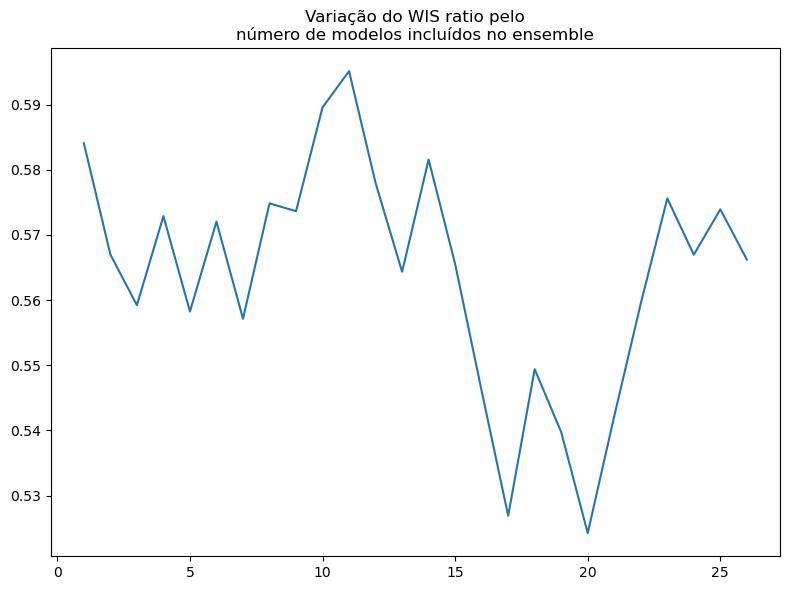

In [15]:
state = 50

df_ = df_wis_rank_gmean.loc[df_wis_rank_gmean.adm_1 == state]

_,ax = plt.subplots(1,1, figsize = (8, 6), sharex=True)

ax.plot(df_.models_included, df_.WIS_ratio)

ax.set_title('Variação do WIS ratio pelo\nnúmero de modelos incluídos no ensemble')

plt.tight_layout()

plt.show()


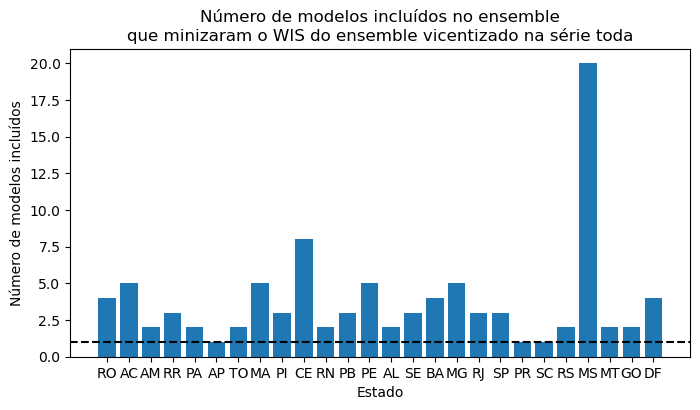

In [16]:
df_m_incl = df_wis_rank_gmean.loc[df_wis_rank_gmean.groupby('adm_1')['WIS_ratio'].idxmin(), ['adm_1', 'models_included']]

df_m_incl['state'] = df_m_incl['adm_1'].replace(code_to_state)

_,ax = plt.subplots(figsize = (8, 4))

ax.bar(df_m_incl.state, df_m_incl.models_included)

ax.axhline(1, color = 'black', linestyle = '--')

ax.set_title('Número de modelos incluídos no ensemble\nque minizaram o WIS do ensemble vicentizado na série toda')

ax.set_xlabel('Estado')
ax.set_ylabel('Número de modelos incluídos')

plt.show()
